In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris # sklearn으로 dataset 접근시 리스트로 접근함
from sklearn.model_selection import train_test_split # train set과 test set을 분리해줌
from sklearn.linear_model import LinearRegression # 선형 회귀 분석 모델
from sklearn.metrics import mean_squared_error, r2_score # 수학공식 모아둔 패키지

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc('font', family='Apple SD Gothic Neo')
plt.rc('axes', unicode_minus=False)
plt.rc('font', family='NanumGothic')
health_data = pd.read_csv('smoking_health_data.csv')

In [6]:
# 1. Sepal Width와 Petal Width의 관계 분석 
#    → 선형 회귀 모델 만들고 R² 비교하기

In [7]:
iris = load_iris().data 

In [8]:
X = iris[:, 0].reshape(-1,1) 

In [9]:
y = iris[:,3]

<Axes: >

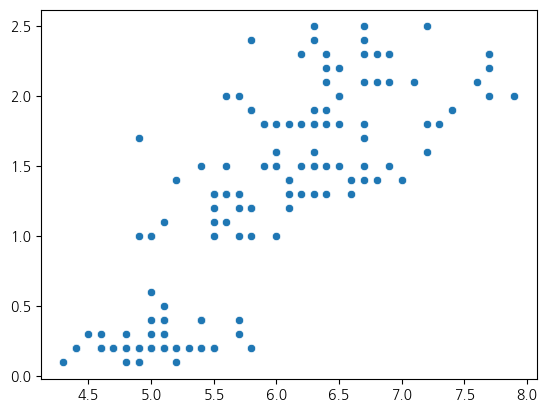

In [10]:
sns.scatterplot(x=X.flatten(),y=y)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [20]:
model = LinearRegression()

In [21]:
model.fit(X_train,y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred = model.predict(X_test) 

In [23]:
mse = mean_squared_error(y_test, y_pred)
mse

0.15414584335079376

In [24]:
r2 = r2_score(y_test, y_pred)
r2

0.7575009893273534

In [66]:
# 2. 당뇨병 데이터 특성 선택
# BMI 예측에 가장 좋은 특성 조합 찾기
#   → 2개, 3개, 5개 특성 조합 비교

In [24]:
df = pd.read_csv('train.csv')
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']].replace(0,None)
df = df.dropna()

Text(0, 0.5, '상관계수')

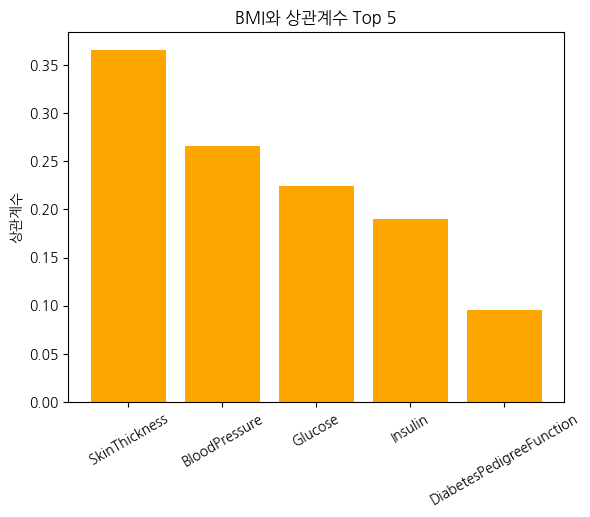

In [25]:
num_data = df.select_dtypes(include=[np.number])
corr_label = num_data.corr()['BMI'].drop(['BMI','Outcome'])
top5 = corr_label.abs().sort_values(ascending=False).head()

plt.bar(x= top5.index, height = top5.values,  color='orange')      
plt.xticks(rotation=30)      
plt.title("BMI와 상관계수 Top 5")                                                  
plt.ylabel("상관계수")

In [26]:
y = df['BMI']

In [27]:
# 2개 특성

In [28]:
feature_2 = ["SkinThickness","BloodPressure"]

In [29]:
X_2 = df[feature_2]

In [30]:
X_2_train, X_2_test, y_2_train, y_2_test = train_test_split(X_2,y, test_size=0.2, random_state=42)

In [31]:
model_2 = LinearRegression()

In [32]:
model_2.fit(X_2_train, y_2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_2_pred = model_2.predict(X_2_test)

In [34]:
mse_2  = mean_squared_error(y_2_test, y_2_pred)

In [35]:
r2_2 = r2_score(y_2_test, y_2_pred)

In [36]:
print("=" * 60)
print(f" {feature_2} 특성의 영향력 ")
print(f"가중치 w: {model_2.coef_[0]:.3f}")
print(f"편향 b: {model_2.intercept_:.3f}")
print(f"MSE: {mse_2:.3f}") # mse로 모델을 평가함 값이 작을수록 좋음
print(f"R² Score: {r2_2:.3f}") # 1.0에 가까울수록 좋고 0.7정도면 괜찮은 모델
print("=" * 60)

 ['SkinThickness', 'BloodPressure'] 특성의 영향력 
가중치 w: 0.142
편향 b: 24.621
MSE: 37.372
R² Score: 0.292


In [37]:
# 3개 특성

In [38]:
feature_3 = ["SkinThickness","BloodPressure","Glucose"]

In [39]:
X_3 = df[feature_3]

In [40]:
X_3_train, X_3_test, y_3_train, y_3_test = train_test_split(X_3,y, test_size=0.2, random_state=42)

In [41]:
model_3 = LinearRegression()

In [42]:
model_3.fit(X_3_train, y_3_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
y_3_pred = model_3.predict(X_3_test)

In [44]:
mse_3  = mean_squared_error(y_3_test, y_3_pred)

In [45]:
r2_3 = r2_score(y_3_test, y_3_pred)

In [46]:
print("=" * 60)
print(f" {feature_3} 특성의 영향력 ")
print(f"가중치 w: {model_3.coef_[0]:.3f}")
print(f"편향 b: {model_3.intercept_:.3f}")
print(f"MSE: {mse_3:.3f}")
print(f"R² Score: {r2_3:.3f}")
print("=" * 60)

 ['SkinThickness', 'BloodPressure', 'Glucose'] 특성의 영향력 
가중치 w: 0.140
편향 b: 19.774
MSE: 36.833
R² Score: 0.302


In [47]:
# 5개 특성

In [48]:
feature_5 = ["SkinThickness","BloodPressure","Glucose","Insulin","DiabetesPedigreeFunction"]

In [49]:
X_5 = df[feature_5]

In [50]:
X_5_train, X_5_test, y_5_train, y_5_test = train_test_split(X_5,y, test_size=0.2, random_state=42)

In [51]:
model_5 = LinearRegression()

In [52]:
model_5.fit(X_5_train, y_5_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
y_5_pred = model_5.predict(X_5_test)

In [54]:
mse_5 = mean_squared_error(y_5_test, y_5_pred)

In [55]:
r2_5 = r2_score(y_5_test, y_5_pred)

In [56]:
print("=" * 60)
print(f" {feature_5} 특성의 영향력 ")
print(f"가중치 w: {model_5.coef_[0]:.3f}")
print(f"편향 b: {model_5.intercept_:.3f}")
print(f"MSE: {mse_5:.3f}")
print(f"R² Score: {r2_5:.3f}")
print("=" * 60)

 ['SkinThickness', 'BloodPressure', 'Glucose', 'Insulin', 'DiabetesPedigreeFunction'] 특성의 영향력 
가중치 w: 0.152
편향 b: 19.341
MSE: 37.171
R² Score: 0.296
